# SMC Sampler for Parameter Estimation

This notebook demonstrates the **SMC Sampler** (Del Moral, Doucet & Jasra, 2006)
for Bayesian parameter estimation of a linear-Gaussian state-space model.

The SMC sampler bridges from a tractable prior to the posterior via a sequence
of **tempered distributions**:

$$\pi_t(\theta) = p(\theta) \cdot p(y \mid \theta)^{\gamma_t}$$

where $0 = \gamma_0 < \gamma_1 < \cdots < \gamma_P = 1$, with the schedule
chosen adaptively to maintain a target Effective Sample Size (ESS).

**Key features demonstrated:**
- Adaptive tempering schedule via ESS targeting
- Resampling + MCMC rejuvenation moves
- Log marginal likelihood (evidence) estimation $\log p(y)$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import sys
import time

sys.path.insert(0, str(Path.cwd().parents[2]))

from particlefilterbox.smc import SMCSampler, Tempering

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
print('Imports OK')

Imports OK


In [2]:
data_path = Path('..') / 'data' / 'simulated_linear_gaussian.csv'
df = pd.read_csv(data_path)
y_obs = df['y_obs'].values
x_true = df['x_true'].values
T = len(df)
print(f'Loaded {T} observations')
df.head()

Loaded 500 observations


,t,x_true,y_obs
0,0,0.487938,-0.552046
1,1,0.838767,1.779331
2,2,-0.178689,-1.480869
3,3,-0.105835,-0.422077
4,4,-0.108944,-0.961987


## Linear-Gaussian State-Space Model

$$x_t = \phi \, x_{t-1} + \eta_t, \quad \eta_t \sim \mathcal{N}(0, \sigma_x^2)$$
$$y_t = x_t + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma_y^2)$$

**True parameters:** $\phi = 0.95$, $\sigma_x = 0.5$, $\sigma_y = 1.0$

We treat these as unknown and estimate them using the SMC sampler with priors:
- $\phi \sim \text{Uniform}(0, 1)$
- $\sigma_x \sim \text{Half-Normal}(0, 1)$
- $\sigma_y \sim \text{Half-Normal}(0, 2)$

## SMC Sampler with Adaptive Tempering

The target distribution is the posterior:

$$\pi(\theta) = p(\theta) \cdot p(y_{1:T} \mid \theta)$$

The SMC sampler constructs a sequence of tempered distributions
$\pi_t(\theta) \propto p(\theta) \cdot p(y \mid \theta)^{\gamma_t}$
with $\gamma_t$ chosen adaptively so that the ESS after reweighting
stays near a target fraction of $N$.

In [3]:
# True parameters
TRUE_PHI = 0.95
TRUE_SIGMA_X = 0.5
TRUE_SIGMA_Y = 1.0

def log_likelihood_lg(theta: np.ndarray, y: np.ndarray) -> float:
    """Log-likelihood via Kalman filter for linear-Gaussian model.

    theta = [phi, sigma_x, sigma_y]
    """
    phi, sigma_x, sigma_y = theta[0], theta[1], theta[2]

    if sigma_x <= 0 or sigma_y <= 0 or abs(phi) >= 1:
        return -np.inf

    Q = sigma_x**2
    R = sigma_y**2
    T = len(y)

    # Kalman filter
    x_pred = 0.0
    P_pred = Q / (1.0 - phi**2)

    log_lik = 0.0
    for t in range(T):
        # Innovation
        v = y[t] - x_pred
        F = P_pred + R

        # Log-likelihood increment
        log_lik += -0.5 * (np.log(2 * np.pi * F) + v**2 / F)

        # Update
        K = P_pred / F
        x_filt = x_pred + K * v
        P_filt = (1.0 - K) * P_pred

        # Predict
        x_pred = phi * x_filt
        P_pred = phi**2 * P_filt + Q

    return log_lik

def log_prior(theta: np.ndarray) -> float:
    """Log prior: phi ~ U(0,1), sigma_x ~ HalfNormal(1), sigma_y ~ HalfNormal(2)."""
    phi, sigma_x, sigma_y = theta[0], theta[1], theta[2]

    if phi <= 0 or phi >= 1 or sigma_x <= 0 or sigma_y <= 0:
        return -np.inf

    lp = 0.0  # Uniform on (0,1) for phi
    lp += stats.halfnorm.logpdf(sigma_x, scale=1.0)
    lp += stats.halfnorm.logpdf(sigma_y, scale=2.0)
    return lp

def log_target(theta: np.ndarray) -> float:
    """Log posterior (unnormalized) = log prior + log likelihood."""
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_lg(theta, y_obs)

def sample_prior(rng: np.random.Generator) -> np.ndarray:
    """Draw from the prior."""
    phi = rng.uniform(0.01, 0.99)
    sigma_x = abs(rng.standard_normal()) * 1.0
    sigma_y = abs(rng.standard_normal()) * 2.0
    if sigma_x < 0.01:
        sigma_x = 0.01
    if sigma_y < 0.01:
        sigma_y = 0.01
    return np.array([phi, sigma_x, sigma_y])

# Test
theta_true = np.array([TRUE_PHI, TRUE_SIGMA_X, TRUE_SIGMA_Y])
print(f'Log-likelihood at true params: {log_likelihood_lg(theta_true, y_obs):.2f}')
print(f'Log-prior at true params: {log_prior(theta_true):.4f}')
print(f'Log-target at true params: {log_target(theta_true):.2f}')

Log-likelihood at true params: -845.02
Log-prior at true params: -1.3947
Log-target at true params: -846.42


In [4]:
# Run SMC Sampler with N=2000, adaptive tempering
sampler = SMCSampler(
    target_logpdf=log_target,
    prior_logpdf=log_prior,
    prior_sample=sample_prior,
    n_particles=2000,
    n_mcmc_moves=5,
    ess_target_ratio=0.5,
    seed=42,
)

t0 = time.time()
results = sampler.run()
elapsed = time.time() - t0

print(f'SMC Sampler completed in {elapsed:.1f}s')
print(f'Number of tempering steps: {results.n_steps}')
print(f'Log marginal likelihood: {results.log_evidence:.2f}')
print()
print(results.summary())

SMC Sampler completed in 51.6s
Number of tempering steps: 7
Log marginal likelihood: -853.02

SMC Results Summary
  N particles:   2000
  K parameters:  3
  N steps:       7
  Log-evidence:  -853.0172
  Final ESS:     1174.1
  Mean acc rate: 0.227

  Parameter summaries:
  Name                  Mean        Std      CI_lo      CI_hi
  -------------------------------------------------------
  param_0             0.9081     0.0257     0.8527     0.9533
  param_1             0.5865     0.0694     0.4648     0.7366
  param_2             1.0158     0.0511     0.9131     1.1147


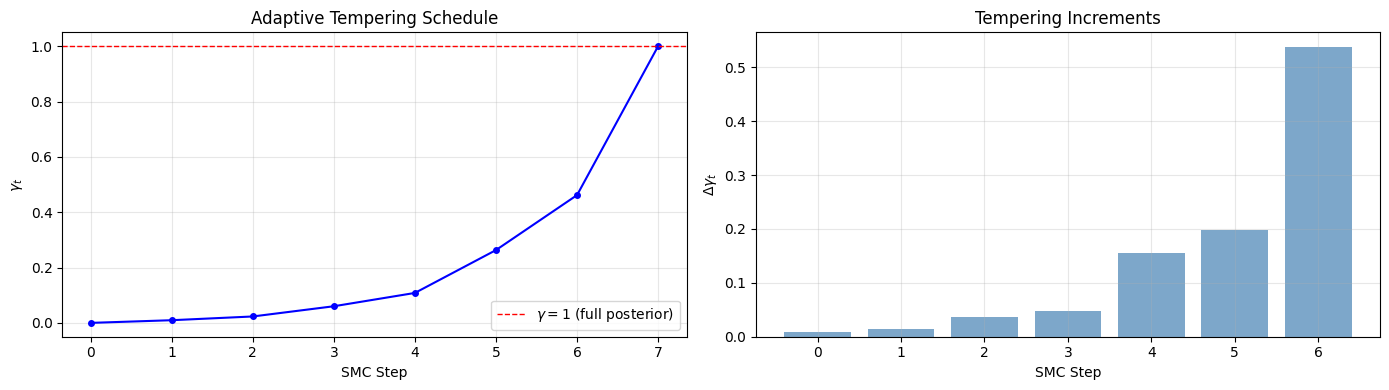

Schedule: 8 stages from 0 to 1.0000


In [5]:
# Plot: Tempering schedule gamma_t
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(results.schedule, 'bo-', ms=4, lw=1.5)
ax.set_xlabel('SMC Step')
ax.set_ylabel(r'$\gamma_t$')
ax.set_title('Adaptive Tempering Schedule')
ax.grid(alpha=0.3)
ax.axhline(1.0, color='red', ls='--', lw=1, label=r'$\gamma = 1$ (full posterior)')
ax.legend()

ax = axes[1]
deltas = np.diff(results.schedule)
ax.bar(range(len(deltas)), deltas, color='steelblue', alpha=0.7)
ax.set_xlabel('SMC Step')
ax.set_ylabel(r'$\Delta\gamma_t$')
ax.set_title('Tempering Increments')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('smc_sampler_schedule.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Schedule: {len(results.schedule)} stages from 0 to {results.schedule[-1]:.4f}')

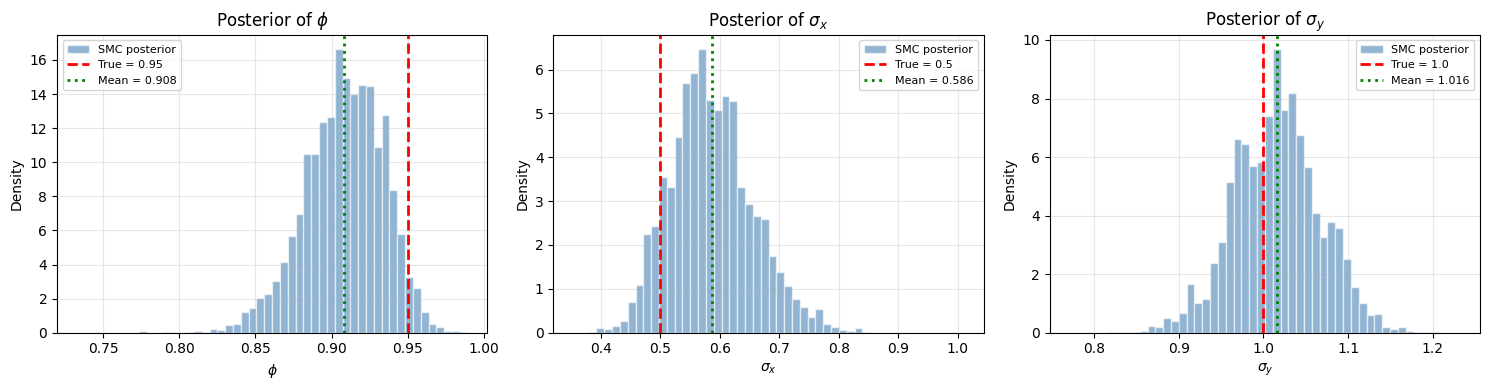

In [6]:
# Plot: Marginal posterior distributions
param_names = [r'$\phi$', r'$\sigma_x$', r'$\sigma_y$']
true_vals = [TRUE_PHI, TRUE_SIGMA_X, TRUE_SIGMA_Y]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for j, (ax, name, true_val) in enumerate(zip(axes, param_names, true_vals)):
    samples = results.particles[:, j]
    weights = results.weights

    # Weighted histogram
    ax.hist(samples, bins=50, weights=weights, density=True,
            color='steelblue', alpha=0.6, edgecolor='white', label='SMC posterior')
    ax.axvline(true_val, color='red', lw=2, ls='--', label=f'True = {true_val}')

    # Weighted mean
    wmean = np.average(samples, weights=weights)
    ax.axvline(wmean, color='green', lw=2, ls=':', label=f'Mean = {wmean:.3f}')

    ax.set_xlabel(name)
    ax.set_ylabel('Density')
    ax.set_title(f'Posterior of {name}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('smc_sampler_posteriors.png', dpi=100, bbox_inches='tight')
plt.show()

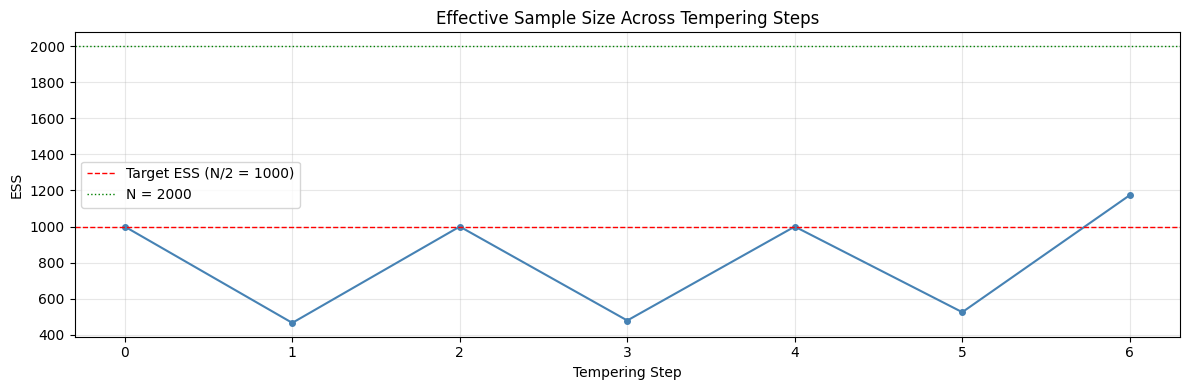

Mean MCMC acceptance rate: 0.227
Min acceptance rate: 0.177
Max acceptance rate: 0.305


In [7]:
# Plot: ESS over tempering steps
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(results.ess_history, 'steelblue', lw=1.5, marker='o', ms=4)
ax.axhline(2000 * 0.5, color='red', ls='--', lw=1, label='Target ESS (N/2 = 1000)')
ax.axhline(2000, color='green', ls=':', lw=1, label='N = 2000')
ax.set_xlabel('Tempering Step')
ax.set_ylabel('ESS')
ax.set_title('Effective Sample Size Across Tempering Steps')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('smc_sampler_ess.png', dpi=100, bbox_inches='tight')
plt.show()

if results.acceptance_rates:
    print(f'Mean MCMC acceptance rate: {np.mean(results.acceptance_rates):.3f}')
    print(f'Min acceptance rate: {np.min(results.acceptance_rates):.3f}')
    print(f'Max acceptance rate: {np.max(results.acceptance_rates):.3f}')

In [8]:
# Log marginal likelihood (evidence) estimation
print('=' * 60)
print('LOG MARGINAL LIKELIHOOD (EVIDENCE) ESTIMATION')
print('=' * 60)
print(f'  log p(y) via SMC sampler: {results.log_evidence:.4f}')
print()

# Compare with log-likelihood at true parameters (not the same as evidence, but useful reference)
ll_true = log_likelihood_lg(theta_true, y_obs)
print(f'  log p(y|theta_true) [likelihood at true params]: {ll_true:.4f}')
print()
print('  Note: log p(y) integrates over all theta, so it is typically')
print('  lower than the likelihood at the MLE or true parameters.')
print('  The SMC estimate of log p(y) can be used for model comparison')
print('  via Bayes factors: log BF(M1 vs M2) = log p(y|M1) - log p(y|M2)')

LOG MARGINAL LIKELIHOOD (EVIDENCE) ESTIMATION
  log p(y) via SMC sampler: -853.0172

  log p(y|theta_true) [likelihood at true params]: -845.0230

  Note: log p(y) integrates over all theta, so it is typically
  lower than the likelihood at the MLE or true parameters.
  The SMC estimate of log p(y) can be used for model comparison
  via Bayes factors: log BF(M1 vs M2) = log p(y|M1) - log p(y|M2)


In [9]:
# Table: Parameter estimates vs true values
means = results.posterior_mean()
stds = results.posterior_std()
ci = results.credible_interval(0.95)

param_labels = ['phi', 'sigma_x', 'sigma_y']
true_values = [TRUE_PHI, TRUE_SIGMA_X, TRUE_SIGMA_Y]

table_data = []
for j, (label, true_val) in enumerate(zip(param_labels, true_values)):
    table_data.append({
        'Parameter': label,
        'True Value': true_val,
        'SMC Mean': f'{means[j]:.4f}',
        'SMC Std': f'{stds[j]:.4f}',
        'CI 2.5%': f'{ci[j, 0]:.4f}',
        'CI 97.5%': f'{ci[j, 1]:.4f}',
        'Within 2 SD': 'Yes' if abs(means[j] - true_val) < 2 * stds[j] else 'No',
    })

results_df = pd.DataFrame(table_data)
print('Parameter Estimates vs True Values')
print('=' * 80)
print(results_df.to_string(index=False))
print()
print(f'Log marginal likelihood: {results.log_evidence:.4f}')
print(f'Number of tempering steps: {results.n_steps}')
print(f'Final ESS: {results.ess_history[-1]:.1f}' if results.ess_history else '')

Parameter Estimates vs True Values
Parameter  True Value SMC Mean SMC Std CI 2.5% CI 97.5% Within 2 SD
      phi        0.95   0.9081  0.0257  0.8527   0.9533         Yes
  sigma_x        0.50   0.5865  0.0694  0.4648   0.7366         Yes
  sigma_y        1.00   1.0158  0.0511  0.9131   1.1147         Yes

Log marginal likelihood: -853.0172
Number of tempering steps: 7
Final ESS: 1174.1


## Conclusions

### Advantages of SMC Sampler vs MCMC

1. **Parallelizable**: Each particle evolves independently, enabling efficient parallelization.

2. **No burn-in**: Unlike MCMC, SMC produces valid samples from the start. The tempering
   schedule gradually transforms the prior into the posterior.

3. **Model evidence**: SMC naturally provides an estimate of the log marginal likelihood
   $\log p(y)$, which is essential for Bayesian model comparison. MCMC requires additional
   methods (harmonic mean, bridge sampling) for this.

4. **Multimodal targets**: The tempering approach can track multiple modes, while MCMC
   may get stuck in one mode.

5. **Adaptive schedule**: The ESS-based adaptive tempering automatically determines
   how many stages are needed, avoiding manual tuning.

### Limitations

- Higher computational cost per effective sample compared to well-tuned MCMC
- MCMC rejuvenation quality depends on proposal covariance estimation
- Memory requirements scale with $N$ (number of particles)

### Next Steps

- See `02_smc2.ipynb` for SMC$^2$ applied to the stochastic volatility model
- See `03_ibis_waste_free.ipynb` for IBIS and waste-free SMC comparisons